# Download and process OpenMesh dataset

This notebook 
* downloads the dataset [OpenMesh (Jacoby et al. 2025)](https://doi.org/10.5281/zenodo.15287692)
* creates sample datasets for different time periods
* loads and inspects CML (Commercial Microwave Link) data
* loads and inspects PWS (Personal Weather Station) data
* fetches and converts ASOS reference data to OpenSense format
* plots comparisons of CML, PWS and ASOS reference data

In [1]:
# Uncomment to install
# !pip install xarray netCDF4 requests tqdm numpy pandas poligrain pypwsqc pyproj matplotlib

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import warnings

import openmesh_data_io as omio
import ws_opensense_conversion as wsoc

warnings.filterwarnings('ignore')

## Configuration

In [3]:
DATA_DIR       = "data/jacoby_2025_OpenMesh/"
SAMPLE_DIR     = "data/samples/"
CML_PATH       = "data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc"
PWS_PATH       = "data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc"
ASOS_META_PATH = "data/jacoby_2025_OpenMesh/meta/ASOS_stations.csv"

## Download and transform OpenMesh dataset

In [4]:
omio.download_openmesh(
    output_dir=DATA_DIR
);

  CML found locally  : data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc


## Load CML dataset

In [5]:
from pathlib import Path

print("DATA_DIR:", omio.DATA_DIR)
raw = omio.DATA_DIR / "raw"
if raw.exists():
  print("Files in raw/:", list(raw.iterdir()))
else:
  print("raw/ folder does not exist!")

DATA_DIR: /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh
Files in raw/: [PosixPath('/Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc'), PosixPath('/Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_opensense_sample_jan.nc'), PosixPath('/Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc')]


In [6]:
ds_cml = omio.load_cml()
print(ds_cml)

  Loaded CML        : {'cml_id': 75, 'sublink_id': 3, 'time': 354241}  ←  data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc
<xarray.Dataset> Size: 322MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 354241)
Coordinates:
  * time          (time) datetime64[ns] 3MB 2023-10-29 ... 2024-07-01
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B 40.7 40.66 40.73 ... 40.66 40.73 40.65
    site_0_lon    (cml_id) float32 300B -73.94 -74.0 -73.95 ... -73.95 -74.0
    site_1_lat    (cml_id) float32 300B 40.69 40.68 40.72 ... 40.66 40.73 40.64
    site_1_lon    (cml_id) float32 300B -73.92 -73.99 -73.98 ... -73.95 -73.95
    length        (cml_id) float32 300B 2.178e+03 2.955e+03 ... 122.4 4.506e+03
    frequency     (cml_id, sublink_id) float32 900B 6.804e+04 6.804e+04 ... nan
    polarization  (cml_id, sublink_id) object 2kB 'v' 'v' 'v' ... 'v' 'v' 'v'
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75

### Slice & select CML data

In [7]:
# ── CML selection ─────────────────────────────────────────────
cml_ids     = ["5", "7", "15", "42"]       # None = all 75
sublink_ids = ["sublink_1"]   # None = all sublinks 

# ── Slice Time window ─────────────────────────────────────────────────────
ds_cml_jan = ds_cml.sel(
    time=slice("2024-01-01", "2024-02-01"),
    cml_id=cml_ids,
    sublink_id=sublink_ids,
)


# ── Inspect ───────────────────────────────────────────────────
print(f"Time     : {str(ds_cml_jan.time.values[0])[:19]}  →  {str(ds_cml_jan.time.values[-1])[:19]}")
print(f"CML IDs  : {ds_cml_jan.cml_id.values}")
print(f"Sublinks : {ds_cml_jan.sublink_id.values}")
print(f"Shape    : {dict(ds_cml_jan.sizes)}")

Time     : 2024-01-01T00:00:00  →  2024-02-01T23:59:00
CML IDs  : ['5' '7' '15' '42']
Sublinks : ['sublink_1']
Shape    : {'cml_id': 4, 'sublink_id': 1, 'time': 46080}


## Create CML samples

Samples are **saved to disk by default** (`→ data/samples/`), returning the file path.
Use `return_type="sample"` to get the `xr.Dataset` in memory instead.

### In-memory sample (no disk write)

In [8]:
ds_sample_custom = omio.create_openmesh_sample(
    ds=ds_cml,
    start_time= "2024-01-15",
    end_time  = "2024-01-25",
    output_dir=SAMPLE_DIR,
    return_type="sample",
    save = False
)

ds_sample_custom

  Source   : provided ds
  Window   : 2024-01-15 00:00:00  →  2024-01-25 00:00:00  (10d)
  CML IDs  : all
  Output   : openmesh_cml_10d.nc
  Timesteps: 14,401
  CML count: 75
  Save     : skipped (save=False)


<xarray.Dataset> Size: 13MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 14401)
Coordinates:
  * time          (time) datetime64[ns] 115kB 2024-01-15 ... 2024-01-25
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B 40.7 40.66 40.73 ... 40.66 40.73 40.65
    site_0_lon    (cml_id) float32 300B -73.94 -74.0 -73.95 ... -73.95 -74.0
    site_1_lat    (cml_id) float32 300B 40.69 40.68 40.72 ... 40.66 40.73 40.64
    site_1_lon    (cml_id) float32 300B -73.92 -73.99 -73.98 ... -73.95 -73.95
    length        (cml_id) float32 300B 2.178e+03 2.955e+03 ... 122.4 4.506e+03
    frequency     (cml_id, sublink_id) float32 900B 6.804e+04 6.804e+04 ... nan
    polarization  (cml_id, sublink_id) object 2kB 'v' 'v' 'v' ... 'v' 'v' 'v'
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 13MB -50.0 -50.0 ... nan
Attributes: (12/15)
    title:                 OpenMesh CML sample (10d), start 2024-01-15
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:                Community NYC Mesh Wireless Network
    history:               2025-11-01: Updated metadata, converted netCDF → O...
    ...                    ...
    comment:               OpenMesh: Wireless Signal Dataset for Opportunisti...
    Conventions:           OpenSense-CML-v1.0
    start_date:            2024-01-15
    end_date:              2024-01-25
    time_range:            2024-01-15T00:00:00 / 2024-01-25T00:00:00
    cml_subset:            all

### Create & Save samples to disk

Ways to create and save a CML sample file.

In [9]:
sep = "═" * 60

# Option A: from an already-loaded dataset → returns saved file path
print(f"\n{sep}")
print("  [A] From loaded dataset (ds_cml) — 1 week, all links")
print(f"{sep}")
path_1w = omio.create_openmesh_sample(
    ds=ds_cml,
    time_interval="1w",
    start_time="2024-01-16",
    output_dir=SAMPLE_DIR,
)

# Option B: standalone (reads from disk) → returns saved file path
print(f"\n{sep}")
print("  [B] Standalone (reads from disk) — 1 day, all links")
print(f"{sep}")
path_1d = omio.create_openmesh_sample(
    time_interval="1d",
    start_time="2024-01-16",
    output_dir=SAMPLE_DIR,
)

# Option C: custom window + specific links → returns file (!) 
print(f"\n{sep}")
print("  [C] 1-hour at 12:00 PM, subset of links")
print(f"{sep}")
cml_sample_1h = omio.create_openmesh_sample(
    ds=ds_cml,
    start_time="2024-01-16T12:00:00",
    end_time="2024-01-16T13:00:00",
    cml_ids=["1", "5", "7", "15", "42"],
    output_dir=SAMPLE_DIR,
    return_type="sample",
)

cml_sample_1h



════════════════════════════════════════════════════════════
  [A] From loaded dataset (ds_cml) — 1 week, all links
════════════════════════════════════════════════════════════
  Source   : provided ds
  Window   : 2024-01-16 00:00:00  →  2024-01-23 00:00:00  (1w)
  CML IDs  : all
  Output   : openmesh_cml_1w.nc
  Timesteps: 10,081
  CML count: 75
  Exists   : openmesh_cml_1w.nc  (skipped — pass replace=True to overwrite)

════════════════════════════════════════════════════════════
  [B] Standalone (reads from disk) — 1 day, all links
════════════════════════════════════════════════════════════
  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc
  Window   : 2024-01-16 00:00:00  →  2024-01-17 00:00:00  (1d)
  CML IDs  : all
  Output   : openmesh_cml_1d.nc
  Timesteps: 1,441
  CML count: 75
  Exists   : openmesh_cml_1d.nc  (skipped — pass replace=True to overwrite)

════════════════════════════════

<xarray.Dataset> Size: 4kB
Dimensions:       (cml_id: 5, sublink_id: 3, time: 61)
Coordinates:
  * time          (time) datetime64[ns] 488B 2024-01-16T12:00:00 ... 2024-01-...
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 20B ...
    site_0_lon    (cml_id) float32 20B ...
    site_1_lat    (cml_id) float32 20B ...
    site_1_lon    (cml_id) float32 20B ...
    length        (cml_id) float32 20B ...
    frequency     (cml_id, sublink_id) float32 60B ...
    polarization  (cml_id, sublink_id) object 120B ...
  * cml_id        (cml_id) <U2 40B '1' '5' '7' '15' '42'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 4kB ...
Attributes: (12/15)
    title:                 OpenMesh CML sample (1h), start 2024-01-16
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:                Community NYC Mesh Wireless Network
    history:               2025-11-01: Updated metadata, converted netCDF → O...
    ...                    ...
    comment:               OpenMesh: Wireless Signal Dataset for Opportunisti...
    Conventions:           OpenSense-CML-v1.0
    start_date:            2024-01-16
    end_date:              2024-01-16
    time_range:            2024-01-16T12:00:00 / 2024-01-16T13:00:00
    cml_subset:            1,5,7,15,42

### Batch creation (shortcut)

`create_openmesh_samples_batch` creates multiple time-interval samples in one call — a shortcut instead of calling `create_openmesh_sample` repeatedly.

In [10]:
batch_samples = omio.create_openmesh_samples_batch(
    intervals=["1h", "1d", "1w", "1mo"],
    start_time="2024-01-16",
    ds=ds_cml,
    output_dir=SAMPLE_DIR,
)

batch_samples



───────────────────────────────────────────────────────
  Interval : 1h
───────────────────────────────────────────────────────
  Source   : provided ds
  Window   : 2024-01-16 00:00:00  →  2024-01-16 01:00:00  (1h)
  CML IDs  : all
  Output   : openmesh_cml_1h.nc
  Timesteps: 61
  CML count: 75
  Exists   : openmesh_cml_1h.nc  (skipped — pass replace=True to overwrite)

───────────────────────────────────────────────────────
  Interval : 1d
───────────────────────────────────────────────────────
  Source   : provided ds
  Window   : 2024-01-16 00:00:00  →  2024-01-17 00:00:00  (1d)
  CML IDs  : all
  Output   : openmesh_cml_1d.nc
  Timesteps: 1,441
  CML count: 75
  Exists   : openmesh_cml_1d.nc  (skipped — pass replace=True to overwrite)

───────────────────────────────────────────────────────
  Interval : 1w
───────────────────────────────────────────────────────
  Source   : provided ds
  Window   : 2024-01-16 00:00:00  →  2024-01-23 00:00:00  (1w)
  CML IDs  : all
  Output   : op

{'1h': PosixPath('data/samples/openmesh_cml_1h.nc'),
 '1d': PosixPath('data/samples/openmesh_cml_1d.nc'),
 '1w': PosixPath('data/samples/openmesh_cml_1w.nc'),
 '1mo': PosixPath('data/samples/openmesh_cml_1mo.nc')}

## Load a saved CML sample & inspect

Re-open the 1-week sample (`path_1w`) that was saved to disk above.

In [11]:
ds_sample = omio.load_cml_sample(path_1w)
print(ds_sample)

  Loaded CML sample : {'cml_id': 75, 'sublink_id': 3, 'time': 10081}  ←  openmesh_cml_1w.nc
<xarray.Dataset> Size: 9MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 10081)
Coordinates:
  * time          (time) datetime64[ns] 81kB 2024-01-16 ... 2024-01-23
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B ...
    site_0_lon    (cml_id) float32 300B ...
    site_1_lat    (cml_id) float32 300B ...
    site_1_lon    (cml_id) float32 300B ...
    length        (cml_id) float32 300B ...
    frequency     (cml_id, sublink_id) float32 900B ...
    polarization  (cml_id, sublink_id) object 2kB ...
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 9MB ...
Attributes: (12/15)
    title:                 OpenMesh CML sample (1w), start 2024-01-16
    file_author:           Dror Jacoby
    institution:           Cellular Environm

## PWS (Personal Weather Stations)

Download, load and create samples from the Weather Underground PWS network data.

### Download PWS data

In [12]:
omio.download_pws_wu(
    output_dir=DATA_DIR
);

  PWS found locally  : data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc


### Load full PWS dataset

In [13]:
import netCDF4 as nc

pws_path = PWS_PATH
root        = nc.Dataset(pws_path)
group_names = list(root.groups.keys())
first       = root.groups[group_names[0]]

print(f"Total stations     : {len(group_names)}")
print(f"First 5 stations   : {group_names[:5]}")
print(f"Variables          : {list(first.variables.keys())}")
print(f"Dimensions         : { {k: v.size for k, v in first.dimensions.items()} }")
print(f"Station ID format  : KNYNEWYO#### (K=USA, NY=state, NEWYO=NYC, ####=number)")
root.close()

Total stations     : 37
First 5 stations   : ['KNYNEWYO1472', 'KNYNEWYO1659', 'KNYNEWYO1288', 'KNYNEWYO1896', 'KNYNEWYO1921']
Variables          : ['rainfall_rate', 'rainfall_amount', 'temperature', 'relative_humidity', 'wind_velocity', 'wind_direction', 'air_pressure', 'time', 'id', 'lat', 'lon', 'elev']
Dimensions         : {'id': 1, 'time': 60339}
Station ID format  : KNYNEWYO#### (K=USA, NY=state, NEWYO=NYC, ####=number)


### Create PWS samples

In [14]:
sep = "═" * 60

# Option A: 1-day sample
print(f"\n{sep}")
print("  [A] PWS — 1 day")
print(f"{sep}")
path_pws_1d = omio.create_pws_sample(
    time_interval="1d",
    start_time="2024-01-15",
    output_dir=SAMPLE_DIR,
)

# Option B: 1-week sample
print(f"\n{sep}")
print("  [B] PWS — 1 week")
print(f"{sep}")
path_pws_1w = omio.create_pws_sample(
    time_interval="1w",
    start_time="2024-01-15",
    output_dir=SAMPLE_DIR,
)

# Option C: custom window
print(f"\n{sep}")
print("  [C] PWS — custom window")
print(f"{sep}")
path_pws_custom = omio.create_pws_sample(
    start_time="2024-01-15",
    end_time="2024-02-15",
    output_dir=SAMPLE_DIR,
)


════════════════════════════════════════════════════════════
  [A] PWS — 1 day
════════════════════════════════════════════════════════════
  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc
  Window   : 2024-01-15 00:00:00  →  2024-01-16 00:00:00  (1d)
  Stations : 37 groups
  Output   : openmesh_wu_pws_1d.nc
  Loaded   : 35 stations, 287 timesteps
  Exists   : openmesh_wu_pws_1d.nc  (skipped — pass replace=True to overwrite)

════════════════════════════════════════════════════════════
  [B] PWS — 1 week
════════════════════════════════════════════════════════════
  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc
  Window   : 2024-01-15 00:00:00  →  2024-01-22 00:00:00  (1w)
  Stations : 37 groups
  Output   : openmesh_wu_pws_1w.nc
  Loaded   : 35 stations, 2,012 timesteps
  Exists   : openmesh_wu_pws_1w.nc  (s

### Load PWS sample in memory

In [15]:
ds_pws_sample = omio.create_pws_sample(
    time_interval="2w",
    start_time="2024-01-15",
    output_dir=SAMPLE_DIR,
    return_type="sample",
)

  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc
  Window   : 2024-01-15 00:00:00  →  2024-01-29 00:00:00  (2w)
  Stations : 37 groups
  Output   : openmesh_wu_pws_2w.nc
  Loaded   : 35 stations, 3,840 timesteps
  Exists   : openmesh_wu_pws_2w.nc  (skipped — pass replace=True to overwrite)


In [16]:
ds_pws_sample

<xarray.Dataset> Size: 8MB
Dimensions:            (id: 35, time: 3840)
Coordinates:
  * id                 (id) <U12 2kB 'KNYNEWYO1472' ... 'KNYNEWYO1053'
  * time               (time) datetime64[ns] 31kB 2024-01-15T00:04:00 ... 202...
    lat                (id) float64 280B ...
    lon                (id) float64 280B ...
    elev               (id) float64 280B ...
Data variables:
    rainfall_rate      (id, time) float64 1MB ...
    rainfall_amount    (id, time) float64 1MB ...
    temperature        (id, time) float64 1MB ...
    relative_humidity  (id, time) float64 1MB ...
    wind_velocity      (id, time) float64 1MB ...
    wind_direction     (id, time) float64 1MB ...
    air_pressure       (id, time) float64 1MB ...
Attributes:
    title:        OpenMesh PWS sample (2w), start 2024-01-15
    start_date:   2024-01-15
    end_date:     2024-01-29
    time_range:   2024-01-15T00:00:00 / 2024-01-29T00:00:00
    source:       https://zenodo.org/records/17508286
    conventions:  OpenSense v1.0

### Inspect a single PWS station

In [22]:
# ── single station ────────────────────────────────────────────
station_id = "KNYNEWYO1472"

ds_pws_station = ds_pws_sample.sel(id=station_id)

print(f"Station  : {station_id}")
print(f"Lat/Lon  : {float(ds_pws_station.lat):.4f}, {float(ds_pws_station.lon):.4f}")
print(f"Elev     : {float(ds_pws_station.elev):.1f} m")
print(f"Time     : {str(ds_pws_station.time.values[0])[:19]}  →  {str(ds_pws_station.time.values[-1])[:19]}")
print(f"Shape    : {dict(ds_pws_station.sizes)}")
print(ds_pws_station)

Station  : KNYNEWYO1472
Lat/Lon  : 40.8200, -73.9400
Elev     : 66.0 m
Time     : 2024-01-15T00:04:00  →  2024-01-28T23:59:00
Shape    : {'time': 3840}
<xarray.Dataset> Size: 246kB
Dimensions:            (time: 3840)
Coordinates:
    id                 <U12 48B 'KNYNEWYO1472'
  * time               (time) datetime64[ns] 31kB 2024-01-15T00:04:00 ... 202...
    lat                float64 8B 40.82
    lon                float64 8B -73.94
    elev               float64 8B 66.0
Data variables:
    rainfall_rate      (time) float64 31kB ...
    rainfall_amount    (time) float64 31kB ...
    temperature        (time) float64 31kB ...
    relative_humidity  (time) float64 31kB ...
    wind_velocity      (time) float64 31kB ...
    wind_direction     (time) float64 31kB ...
    air_pressure       (time) float64 31kB ...
Attributes:
    title:        OpenMesh PWS sample (2w), start 2024-01-15
    start_date:   2024-01-15
    end_date:     2024-01-29
    time_range:   2024-01-15T00:00:00 / 2024-0

## ASOS reference data

Fetch 1-minute ASOS precipitation from the IEM API for the same period
as the CML samples and save a small OpenSense-style sample NetCDF.

### Load ASOS station metadata

Load or discover ASOS stations in the NYC metro area. If a local CSV exists it is used directly; otherwise stations are fetched from the IEM GeoJSON API.

In [23]:
# Fetch ASOS observations & save as OpenSense NetCDF

# Fetch 1-minute data from the IEM API, convert to an OpenSense-format `xr.Dataset`, and write a compressed NetCDF sample.
from pathlib import Path

meta = wsoc.load_asos_metadata(ASOS_META_PATH) if Path(ASOS_META_PATH).exists() else wsoc.fetch_asos_stations_nyc()
print(f"  Stations ({len(meta)}): {meta.index.tolist()}")

  Stations (3): ['KNYC', 'KJFK', 'KLGA']


In [24]:
from datetime import datetime

start_dt  = datetime(2024, 1, 15)
end_dt    = datetime(2024, 1, 30)
stations  = ["JFK", "EWR", "LGA", "NYC"]
variables = ["precip_amount", "precip_rate", "temperature", "wind_speed"]

asos_raw = wsoc.fetch_asos_raw(start_dt, end_dt, stations, variables=variables)
ds_asos  = wsoc.to_opensense_dataset(asos_raw, source="asos", meta=meta, start_dt=start_dt, end_dt=end_dt)
path     = wsoc.save_opensense_dataset(ds_asos, output_dir=SAMPLE_DIR)

print(f"  Shape : {dict(ds_asos.sizes)}")
print(f"  Time  : {str(ds_asos.time.values[0])[:19]}  →  {str(ds_asos.time.values[-1])[:19]}")
print(f"  Vars  : {list(ds_asos.data_vars)}")
print(ds_asos)

  Fetching JFK ... 20,831 records
  Fetching EWR ... 9,834 records
  Fetching LGA ... 20,938 records
  Fetching NYC ... 18,674 records
  Exists : ASOS_2024-01-15_2024-01-30.nc  (skipped — pass replace=True to overwrite)
  Shape : {'id': 4, 'time': 21066}
  Time  : 2024-01-15T00:00:00  →  2024-01-29T23:59:00
  Vars  : ['precip_amount', 'precip_rate', 'temperature', 'wind_speed']
<xarray.Dataset> Size: 3MB
Dimensions:        (id: 4, time: 21066)
Coordinates:
  * id             (id) <U3 48B 'JFK' 'EWR' 'LGA' 'NYC'
  * time           (time) datetime64[ns] 169kB 2024-01-15 ... 2024-01-29T23:5...
    lat            (id) float64 32B nan nan nan nan
    lon            (id) float64 32B nan nan nan nan
    elev           (id) float64 32B nan nan nan nan
Data variables:
    precip_amount  (id, time) float64 674kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip_rate    (id, time) float64 674kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    temperature    (id, time) float64 674kB 0.0 0.0 0.0 ... 2.778 2.77

## Create all datasets

Helper function that creates CML, PWS and ASOS samples for a given time window in one call.

In [26]:
START_TIME = "2024-01-15"
END_TIME   = "2024-01-25"
# choose sensor id (none for all ids)
CML_IDS  = None
PWS_IDS  = None #["KNYNEWYO1942", "KNYNEWYO1432", "KNYNEWYO1622", "KNYNEWYO1472"]
ASOS_IDS = ["LGA", "NYC", "JFK", "EWR"]

samples = omio.create_all_datasets(
    start_time=START_TIME,
    end_time=END_TIME,
    cml_ids=CML_IDS,
    pws_ids=PWS_IDS,
    asos_ids=ASOS_IDS,
    output_dir=SAMPLE_DIR,
    include_date=False,
    save=   True
)


───────────────────────────────────────────────────────
  CML
───────────────────────────────────────────────────────
  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc
  Window   : 2024-01-15 00:00:00  →  2024-01-25 00:00:00  (10d)
  CML IDs  : all
  Output   : openmesh_cml_10d.nc
  Timesteps: 14,401
  CML count: 75
  Saved    : openmesh_cml_10d.nc  (0.46 MB)

───────────────────────────────────────────────────────
  PWS
───────────────────────────────────────────────────────
  Source   : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc
  Window   : 2024-01-15 00:00:00  →  2024-01-25 00:00:00  (10d)
  Stations : 37 groups
  Output   : openmesh_wu_pws_10d.nc
  Loaded   : 35 stations, 2,849 timesteps
  Saved    : openmesh_wu_pws_10d.nc  (1.04 MB)

───────────────────────────────────────────────────────
  ASOS
──────────────

### Overview plot

  Loaded CML sample : {'cml_id': 75, 'sublink_id': 3, 'time': 14401}  ←  openmesh_cml_10d.nc
  Loaded PWS sample : {'id': 35, 'time': 2849}  ←  openmesh_wu_pws_10d.nc


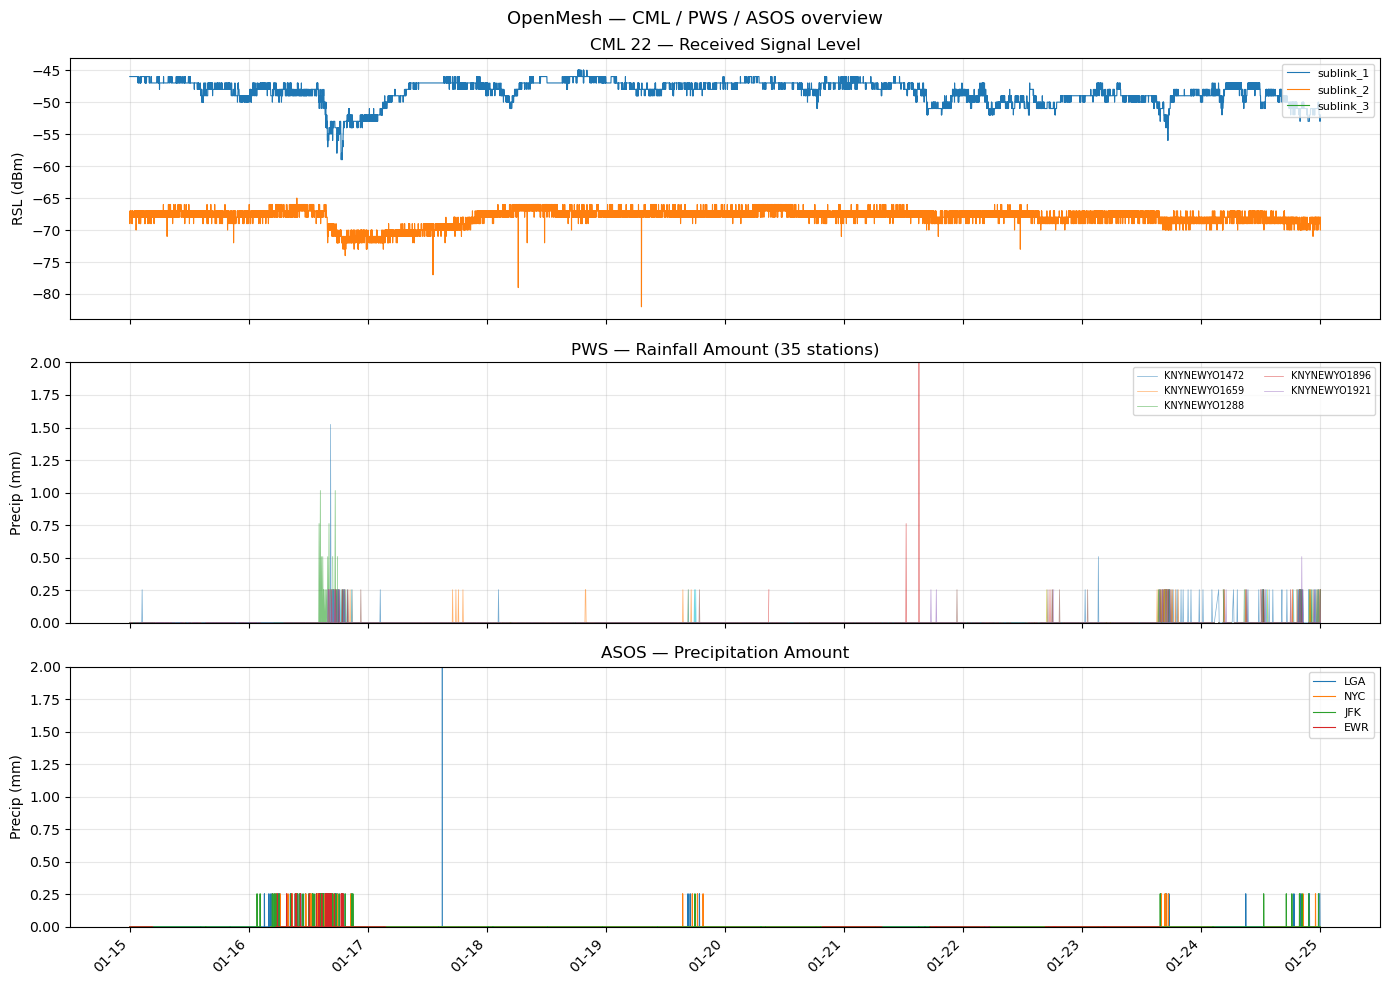

In [27]:
import matplotlib.dates as mdates

# ── load samples ──────────────────────────────────────────────
ds_cml  = omio.load_cml_sample(samples["cml"])
ds_pws  = omio.load_pws_sample(samples["pws"])
ds_asos = xr.open_dataset(samples["asos"])

# ── plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# CML RSL
ax = axes[0]
for sublink in ds_cml.sublink_id.values:
    rsl = ds_cml.rsl.sel(cml_id="22", sublink_id=sublink)
    ax.plot(ds_cml.time.values, rsl.values, lw=0.8, label=sublink)
ax.set_ylabel("RSL (dBm)")
ax.set_title("CML 22 — Received Signal Level")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)

# PWS precipitation
ax = axes[1]
for i, sid in enumerate(ds_pws.id.values):
    rain = ds_pws["rainfall_amount"].sel(id=sid)
    label = str(sid) if i < 5 else None
    ax.plot(ds_pws.time.values, rain.values, lw=0.5, alpha=0.6, label=label)
ax.set_ylabel("Precip (mm)")
ax.set_ylim(0, 2)
ax.set_title(f"PWS — Rainfall Amount ({len(ds_pws.id)} stations)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.grid(alpha=0.3)

# ASOS precipitation
ax = axes[2]
for sid in ds_asos.id.values:
    precip = ds_asos["precip_amount"].sel(id=sid)
    ax.plot(ds_asos.time.values, precip.values, lw=0.8, label=str(sid))
ax.set_ylabel("Precip (mm)")
ax.set_ylim(0, 2)
ax.set_title("ASOS — Precipitation Amount")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.suptitle("OpenMesh — CML / PWS / ASOS overview", fontsize=13)
plt.tight_layout()
plt.show()

---

## Summary

All three data sources have been downloaded, sampled and plotted:

| Source | Description | Format |
|--------|-------------|--------|
| **CML** | 75 commercial microwave links, 15-min resolution | `xr.Dataset` (cml_id, sublink_id, time) |
| **PWS** | ~200 Weather Underground personal weather stations, 5-min resolution | `xr.Dataset` (id, time) |
| **ASOS** | NOAA airport stations (JFK, EWR, LGA, NYC), 1-min resolution | `xr.Dataset` (id, time) |

Sample files are saved under `data/samples/` and can be loaded independently with `omio.load_cml_sample()`, `omio.load_pws_sample()`, or `xr.open_dataset()`.